#  lose

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, log_loss, confusion_matrix,
    classification_report, precision_recall_fscore_support,
    precision_recall_curve, average_precision_score,
    roc_auc_score
)

from imblearn.over_sampling import SMOTE

In [4]:
data=pd.read_csv(r'F:\graduation project\data\Code\final\ecg 60s 10min\features\combined_data.csv')

In [5]:
label_counts = data['label'].value_counts().reset_index()
label_counts.columns = ['Label', 'Count']
label_counts

,Label,Count
0,normal,108328
1,preictal,9575
2,postictal,7653
3,ictal,3003


In [6]:
def convert(df, label_col='label'):

    df = df.copy()
    df.loc[df[label_col] == 'postictal', label_col] = 'normal'
    return df
data = convert(data)

In [7]:
def Encode_Labels(df, label_col='label'):
 
    encoder = LabelEncoder()
    df['encoded_label'] = encoder.fit_transform(df[label_col])

    print(" Multiclass encoding applied successfully!")
    print("Class mapping:")
    for cls, code in zip(encoder.classes_, encoder.transform(encoder.classes_)):
        print(f"  {cls} → {code}")

    return df
data = Encode_Labels(data)

 Multiclass encoding applied successfully!
Class mapping:
  ictal → 0
  normal → 1
  preictal → 2
  nan → 3


In [8]:
label_counts = data['encoded_label'].value_counts().reset_index()
label_counts.columns = ['Label', 'Count']
label_counts

,Label,Count
0,1,115981
1,3,61032
2,2,9575
3,0,3003


In [9]:
label_counts = data['status'].value_counts().reset_index()
label_counts.columns = ['Label', 'Count']
label_counts

,Label,Count
0,success,128532
1,error: cannot convert float NaN to integer,9
2,error: index 9 is out of bounds for axis 0 wit...,9
3,error: integer division or modulo by zero,6
4,error: index 10 is out of bounds for axis 0 wi...,3


In [10]:
data= data[data['status'] == 'success']
label_counts = data['status'].value_counts().reset_index()
label_counts.columns = ['Label', 'Count']
label_counts

,Label,Count
0,success,128532


In [11]:
label_counts = data['encoded_label'].value_counts().reset_index()
label_counts.columns = ['Label', 'Count']
label_counts

,Label,Count
0,1,115966
1,2,9575
2,0,2991


In [12]:
data.columns

Index(['subject', 'run', 'sex', 'start_time', 'end_time', 'eventtype', 'label',
       'signal', 'times', 'R_peaks', 'RR_intervals_ms', 'HR_series', 'status',
       'meanHR', 'stdHR', 'minHR', 'maxHR', 'Delta_HR', 'meanRR_ms', 'SDNN_ms',
       'RMSSD_ms', 'pNN50', 'meanHRV_bpm', 'mean_ecg', 'std_ecg', 'rms_ecg',
       'ptp_ecg', 'total_power_ecg', 'bp_0_5_3_ecg', 'n_beats',
       'encoded_label'],
      dtype='object')

In [13]:
features = [col for col in data.columns if col not in [
    'subject','encoded_label','label','run','sex',
    'start_time','end_time','eventtype',
    'signal','times','R_peaks','RR_intervals_ms',
    'HR_series','status'
]]

subjects = data['subject'].unique()

In [16]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_recall_fscore_support,
    precision_recall_curve,
    average_precision_score,
    roc_auc_score
)
from sklearn.preprocessing import label_binarize
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt


In [17]:
all_y_true = []
all_y_score = []

acc_list = []
loss_list = []
subjects_list = []

In [18]:
for sub in subjects:

    train = data[data['subject'] != sub]
    test  = data[data['subject'] == sub]

    if len(train) == 0 or len(test) == 0:
        continue

    X_train = train[features]
    y_train = train['encoded_label']

    X_test = test[features]
    y_test = test['encoded_label']

    # SMOTE
    smote = SMOTE(random_state=42)
    X_train, y_train = smote.fit_resample(X_train, y_train)

    # Model
    model = RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    # Predictions
    y_score = model.predict_proba(X_test)
    y_pred = np.argmax(y_score, axis=1)

    # Metrics per subject
    acc = accuracy_score(y_test, y_pred)
    loss = log_loss(y_test, y_score)

    acc_list.append(acc)
    loss_list.append(loss)
    subjects_list.append(sub)

    all_y_true.extend(y_test)
    all_y_score.append(y_score)


In [19]:
all_y_true  = np.array(all_y_true)
all_y_score = np.vstack(all_y_score)
all_y_pred  = np.argmax(all_y_score, axis=1)


In [20]:
labels = [0,1,2]

cm = confusion_matrix(all_y_true, all_y_pred, labels=labels)

print("\nCONFUSION MATRIX:\n")
print(pd.DataFrame(cm,
      index=['ictal','normal','preictal'],
      columns=['ictal','normal','preictal']))



CONFUSION MATRIX:

          ictal  normal  preictal
ictal       757    2124       110
normal     5355   95477     15134
preictal    216    8011      1348


In [21]:
print("\nCLASSIFICATION REPORT:\n")
print(classification_report(
    all_y_true,
    all_y_pred,
    labels=labels,
    target_names=['ictal','normal','preictal'],
    zero_division=0
))



CLASSIFICATION REPORT:

              precision    recall  f1-score   support

       ictal       0.12      0.25      0.16      2991
      normal       0.90      0.82      0.86    115966
    preictal       0.08      0.14      0.10      9575

    accuracy                           0.76    128532
   macro avg       0.37      0.41      0.38    128532
weighted avg       0.82      0.76      0.79    128532



In [ ]:
_, _, f1, _ = precision_recall_fscore_support(
    all_y_true, all_y_pred, labels=labels, zero_division=0
)

macro_f1 = np.mean(f1)

y_true_bin = label_binarize(all_y_true, classes=[0,1,2])

roc_auc = roc_auc_score(
    y_true_bin,
    all_y_score,
    multi_class='ovr',
    average='macro'
)

print(f"\nMacro F1-score: {macro_f1:.4f}")
print(f"Macro ROC-AUC: {roc_auc:.4f}")

precision, recall, f1, _ = precision_recall_fscore_support(
    all_y_true, all_y_pred, labels=labels, zero_division=0
)

print("\nPREICTAL PERFORMANCE:\n")
print(f"Precision: {precision[2]:.4f}")
print(f"Recall   : {recall[2]:.4f}")
print(f"F1-score : {f1[2]:.4f}")  


Macro F1-score: 0.3758
Macro ROC-AUC: 0.5949

PREICTAL PERFORMANCE:

Precision: 0.0812
Recall   : 0.1408
F1-score : 0.1030


In [35]:
from sklearn.metrics import precision_recall_fscore_support, roc_auc_score
from sklearn.preprocessing import label_binarize
import numpy as np

labels = [0, 1, 2]

# ===============================
# F1 Score
# ===============================
precision, recall, f1, _ = precision_recall_fscore_support(
    all_y_true,
    all_y_pred,
    labels=labels,
    zero_division=0
)

macro_f1 = np.mean(f1)

# ===============================
# ROC-AUC (OvR)
# ===============================
y_true_bin = label_binarize(all_y_true, classes=[0,1,2])

roc_auc = roc_auc_score(
    y_true_bin,
    all_y_score,
    multi_class='ovr',
    average='macro'
)

print("\n==============================")
print("LOSO GLOBAL METRICS")
print("==============================")
print(f"Macro F1-score : {macro_f1:.4f}")
print(f"Macro ROC-AUC  : {roc_auc:.4f}")


class_names = ['ictal', 'normal', 'preictal']

print("\n==============================")
print("CLASS-WISE PERFORMANCE (LOSO)")
print("==============================")

for i, cls in enumerate(class_names):
    print(f"\nClass: {cls}")
    print(f"Precision: {precision[i]:.4f}")
    print(f"Recall   : {recall[i]:.4f}")
    print(f"F1-score : {f1[i]:.4f}")


LOSO GLOBAL METRICS
Macro F1-score : 0.3758
Macro ROC-AUC  : 0.5949

CLASS-WISE PERFORMANCE (LOSO)

Class: ictal
Precision: 0.1196
Recall   : 0.2531
F1-score : 0.1625

Class: normal
Precision: 0.9040
Recall   : 0.8233
F1-score : 0.8618

Class: preictal
Precision: 0.0812
Recall   : 0.1408
F1-score : 0.1030


In [36]:
print("\n==============================")
print("SEIZURE-FOCUSED LOSO METRICS")
print("==============================")

ictal_idx = 0
preictal_idx = 2

print(f"Ictal Recall    : {recall[ictal_idx]:.4f}")
print(f"Preictal Recall : {recall[preictal_idx]:.4f}")
print(f"Preictal F1     : {f1[preictal_idx]:.4f}")


SEIZURE-FOCUSED LOSO METRICS
Ictal Recall    : 0.2531
Preictal Recall : 0.1408
Preictal F1     : 0.1030


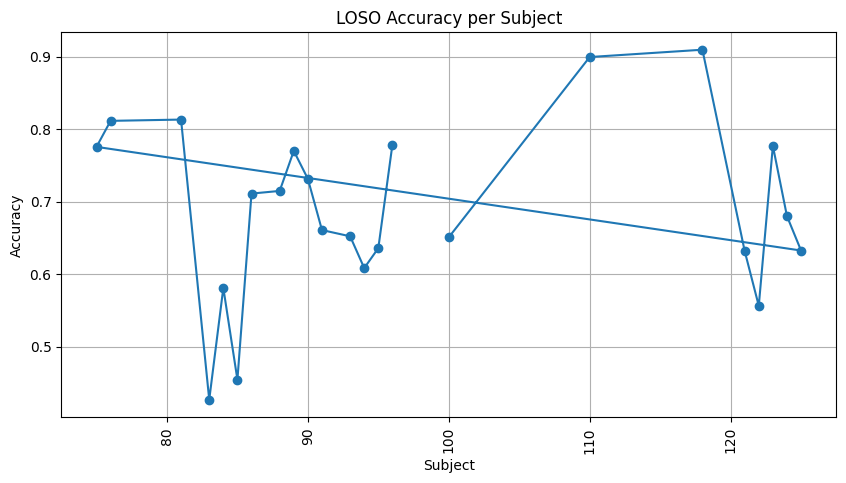

In [24]:
plt.figure(figsize=(10,5))
plt.plot(subjects_list, acc_list, marker='o')
plt.xticks(rotation=90)
plt.title("LOSO Accuracy per Subject")
plt.xlabel("Subject")
plt.ylabel("Accuracy")
plt.grid()
plt.show()

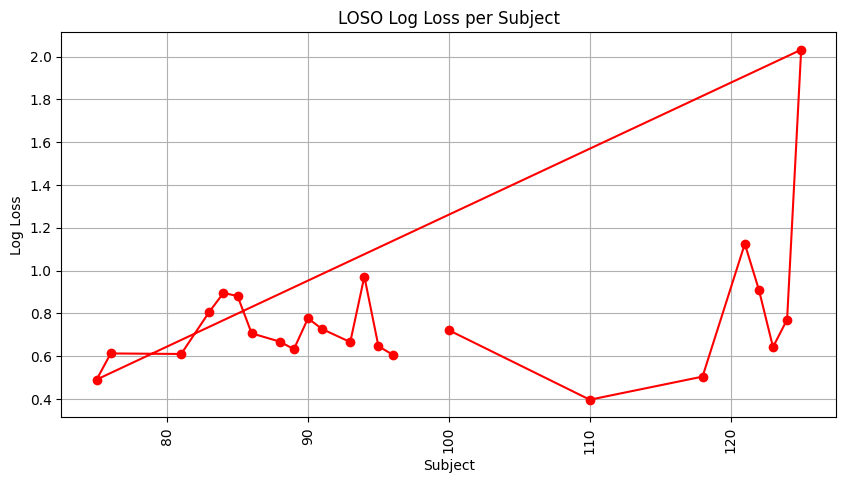

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(subjects_list, loss_list, marker='o', color='red')
plt.xticks(rotation=90)
plt.title("LOSO Log Loss per Subject")
plt.xlabel("Subject")
plt.ylabel("Log Loss")
plt.grid()
plt.show()


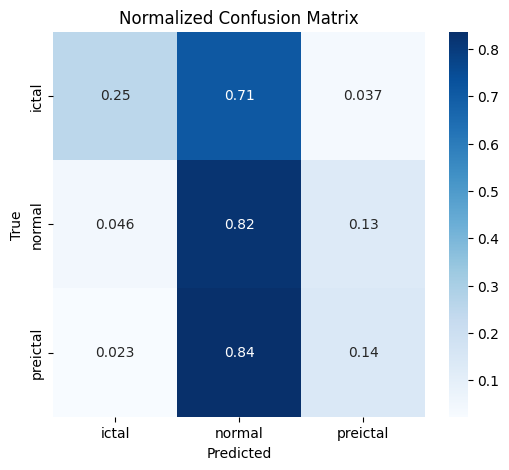

In [31]:
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(6,5))
sns.heatmap(
    cm_norm,
    annot=True,
    cmap="Blues",
    xticklabels=['ictal','normal','preictal'],
    yticklabels=['ictal','normal','preictal']
)
plt.title("Normalized Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

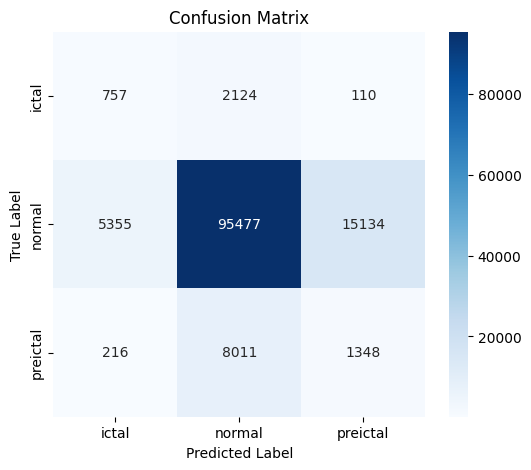

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

labels = [0, 1, 2]
class_names = ['ictal', 'normal', 'preictal']

# Confusion Matrix
cm = confusion_matrix(all_y_true, all_y_pred, labels=labels)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,        # يكتب القيم داخل المربعات
    fmt='d',           # integer format
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [27]:
precision, recall, f1, _ = precision_recall_fscore_support(
    all_y_true, all_y_pred, labels=labels, zero_division=0
)

print("\nPREICTAL PERFORMANCE:\n")
print(f"Precision: {precision[2]:.4f}")
print(f"Recall   : {recall[2]:.4f}")
print(f"F1-score : {f1[2]:.4f}")  


PREICTAL PERFORMANCE:

Precision: 0.0812
Recall   : 0.1408
F1-score : 0.1030


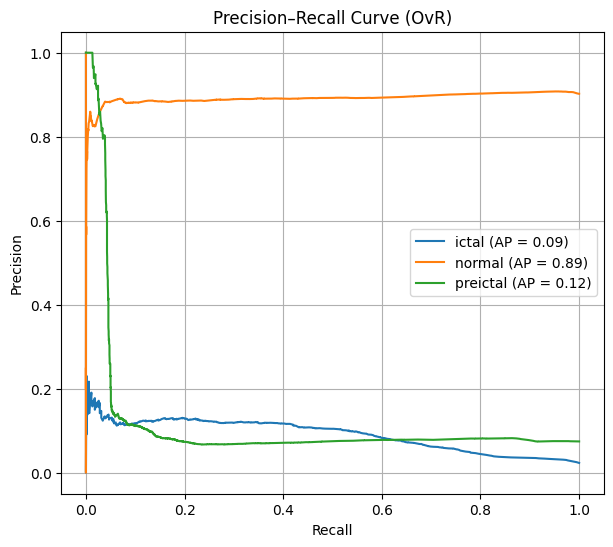

In [28]:
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# ===============================
# Binarize labels
# ===============================
y_true_bin = label_binarize(all_y_true, classes=[0, 1, 2])

class_names = ['ictal', 'normal', 'preictal']

plt.figure(figsize=(7,6))

# ===============================
# Plot PR Curve for each class
# ===============================
for i in range(3):

    precision, recall, _ = precision_recall_curve(
        y_true_bin[:, i],
        all_y_score[:, i]
    )

    ap = average_precision_score(
        y_true_bin[:, i],
        all_y_score[:, i]
    )

    plt.plot(recall, precision, label=f"{class_names[i]} (AP = {ap:.2f})")

# ===============================
# Plot formatting
# ===============================
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve (OvR)")
plt.legend()
plt.grid()
plt.show()